In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\mahek\Downloads\mydata\zomato.csv")

In [3]:
print(df.columns)

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='str')


In [ ]:
df["rate"] = df["rate"].astype(str)
df["rate"] = df["rate"].str.replace("/5", "", regex=False)
df["rate"] = pd.to_numeric(df["rate"], errors="coerce")
ratings = df["rate"].dropna()

Q1 = ratings.quantile(0.25)
Q3 = ratings.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR


df["rate"] = df["rate"].str.replace("/5", "", regex=False)
df["rate"] = pd.to_numeric(df["rate"], errors="coerce")


ratings = df["rate"].dropna()

Q1 = ratings.quantile(0.25)
Q3 = ratings.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df["rate"] < lower_limit) | (df["rate"] > upper_limit)]

print("Indices of outliers:")
print(outliers.index.tolist())


Indices of outliers:
[1532, 1570, 1573, 1637, 1647, 2028, 2030, 2044, 2048, 2121, 2222, 2317, 3915, 4009, 4250, 4287, 4616, 4640, 4665, 4869, 5023, 5473, 5586, 5963, 6300, 6313, 6341, 6598, 6783, 6929, 6994, 7154, 7207, 7492, 7512, 7795, 7801, 8020, 8064, 8126, 8171, 8226, 8241, 8498, 9520, 9856, 9867, 10713, 11273, 11335, 11439, 11588, 11706, 12120, 12540, 12699, 12808, 12828, 13259, 13851, 14231, 14811, 15049, 15093, 15903, 16074, 16508, 16630, 16833, 16926, 17134, 17482, 17612, 18243, 18282, 18317, 18320, 18322, 18828, 18840, 18917, 19004, 19195, 19305, 19363, 20735, 21544, 22435, 22586, 22885, 22929, 22934, 23261, 23497, 23505, 23506, 23574, 24148, 24781, 24998, 25390, 25463, 26177, 26302, 27076, 27373, 27644, 28876, 29473, 30288, 30597, 31631, 31831, 32359, 33128, 34411, 34993, 35836, 36141, 37369, 37510, 37712, 38100, 38187, 38751, 38870, 38889, 38924, 39621, 39797, 40227, 40373, 40580, 40614, 40698, 40788, 40842, 41015, 41060, 41255, 41271, 41278, 41592, 41690, 41709, 41713, 417

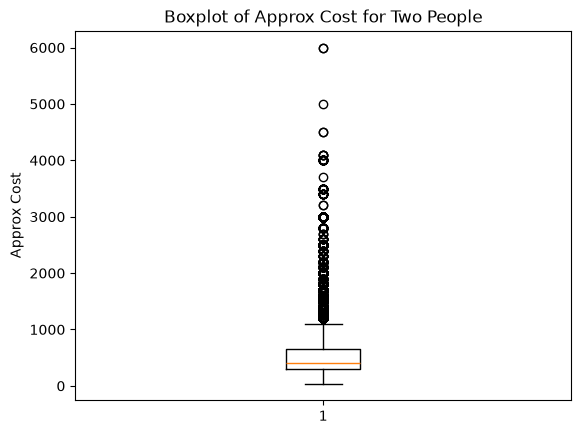

In [ ]:

import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\mahek\Downloads\mydata\zomato.csv")

df["approx_cost(for two people)"] = df["approx_cost(for two people)"].str.replace(",", "", regex=False)
df["approx_cost(for two people)"] = pd.to_numeric(
    df["approx_cost(for two people)"],
    errors="coerce"
)

cost = df["approx_cost(for two people)"].dropna()

plt.boxplot(cost)

plt.title("Boxplot of Approx Cost for Two People")
plt.ylabel("Approx Cost")

plt.show()

In [9]:
df = pd.read_csv(r"C:\Users\mahek\Downloads\bbbb\transactions.csv", sep=";")
print(df.columns)

Index(['Transaction ID,Timestamp,Sender Name,Sender UPI ID,Receiver Name,Receiver UPI ID,Amount (INR),Status'], dtype='str')


In [ ]:


df = pd.read_csv(r"C:\Users\mahek\Downloads\bbbb\transactions.csv")

print(df.columns.tolist())

['Transaction ID', 'Timestamp', 'Sender Name', 'Sender UPI ID', 'Receiver Name', 'Receiver UPI ID', 'Amount (INR)', 'Status']


In [ ]:



df = pd.read_csv(r"C:\Users\mahek\Downloads\bbbb\transactions.csv")


lower_limit = df["Amount (INR)"].quantile(0.05)
upper_limit = df["Amount (INR)"].quantile(0.95)
df["Amount (INR)"] = df["Amount (INR)"].clip(
    lower=lower_limit,
    upper=upper_limit
)

print(df["Amount (INR)"].describe())

count    1000.000000
mean     4997.712795
std      2832.056952
min       516.436000
25%      2521.620000
50%      4951.435000
75%      7315.835000
max      9509.315500
Name: Amount (INR), dtype: float64


In [14]:
import pandas as pd

df = pd.read_excel(r"C:\Users\mahek\Downloads\aaa\flipkart_products.xlsx")


print(df.columns)
import pandas as pd

df = pd.read_excel(r"C:\Users\mahek\Downloads\aaa\flipkart_products.xlsx")


df["discounted_price"] = pd.to_numeric(df["discounted_price"], errors="coerce")


print(df[["discounted_price"]].head())
print(df["discounted_price"].dtype)

Index(['uniq_id', 'crawl_timestamp', 'product_url', 'product_name',
       'product_category_tree', 'pid', 'retail_price', 'discounted_price',
       'image', 'is_FK_Advantage_product', 'description', 'product_rating',
       'overall_rating', 'brand', 'product_specifications'],
      dtype='str')
   discounted_price
0             379.0
1           22646.0
2             499.0
3             267.0
4             210.0
float64


In [ ]:

songs_data = pd.read_json("song.json")

print(songs_data.columns.tolist())

['Song', 'Artist', 'Album', 'Streams', 'Genre']


In [ ]:

songs_data = pd.read_json("song.json")

songs_data["Genre"] = songs_data["Genre"].apply(
    lambda x: True if str(x).strip().lower() == "pop" else False
)

print(songs_data)

                 Song             Artist                     Album  \
0            Espresso  Sabrina Carpenter            Short n' Sweet   
1  Birds of a Feather      Billie Eilish      Hit Me Hard and Soft   
2    Beautiful Things       Benson Boone  Fireworks & Rollerblades   

      Streams  Genre  
0   980000000   True  
1  1200000000   True  
2  1100000000  False  
